# Notebook 1: Dataset Preparation and Archetype Discovery

CFPB Fraud Intelligence project. Team: Samuel Tong, Michael Wicaksono, Liang Wang.

This notebook covers the dataset preparation half of the project:

1. Load the CFPB complaint data
2. Explore it so we understand what we are working with
3. Clean and preprocess the narratives
4. Discover scam archetypes with unsupervised clustering (Phase 1)
5. Validate the discovered archetypes
6. Build stratified train, validation, and test splits

The output of this notebook is a labeled dataset that Notebook 2 uses to train
the classifier.

Run this on a GPU runtime for the discovery step. A CPU works for everything
else but the embedding and clustering step will be slow without a GPU.


## 1. Install dependencies

In [1]:
!pip install --user -q sentence-transformers umap-learn hdbscan bertopic gensim scikit-learn pandas numpy matplotlib


## 2. Configuration

We keep every setting in one cell so there is a single place to change paths or
hyperparameters. This is the notebook version of the config file in the repo.


In [2]:
import re, numpy as np, pandas as pd
from pathlib import Path

# ---- paths ----
RAW = Path("complaints.csv")               # put the CFPB export here
CLEAN = Path("complaints_clean.csv.gz")    # cleaned output
LABELED = Path("discovery_output.csv.gz")  # cleaned + archetype labels

# ---- column names from the CFPB export ----
COL_NARR = "Consumer complaint narrative"
COL_TAGS = "Tags"
COL_ID   = "Complaint ID"
COL_SUB  = "Sub-product"
COL_PROD = "Product"

# ---- preprocessing settings ----
MIN_WORDS = 10       # drop narratives shorter than this
MAX_WORDS = 512      # truncate longer narratives to this many words
OLDER_TAG = "Older American"

# ---- discovery hyperparameters (Phase 1) ----
EMBED_MODEL = "all-MiniLM-L6-v2"
UMAP_N_COMPONENTS = 5
UMAP_N_NEIGHBORS = 15
UMAP_MIN_DIST = 0.0
HDBSCAN_MIN_CLUSTER_SIZE = 300
SEED = 42

print("Config loaded.")


Config loaded.


## 3. Load the data

Our data source is the CFPB Consumer Complaint Database, a public database of
consumer complaints about financial products maintained by the U.S. Consumer
Financial Protection Bureau. We use the fraud and money transfer subset, filtered
to complaints that include a written consumer narrative, since the narrative text
is what our models learn from.


In [3]:
df = pd.read_csv(RAW, low_memory=False)
print(f"Raw rows: {len(df):,}")
print(f"Columns: {list(df.columns)}")

# Keep only rows that have a narrative to work with
df = df[df[COL_NARR].notna()].copy()
df[COL_NARR] = df[COL_NARR].astype(str)
print(f"Rows with a narrative: {len(df):,}")


Raw rows: 25,777
Columns: ['Date received', 'Product', 'Sub-product', 'Consumer complaint narrative', 'Company public response', 'Company', 'State', 'ZIP code', 'Tags', 'Date sent to company', 'Company response to consumer', 'Timely response?', 'Consumer disputed?', 'Complaint ID']
Rows with a narrative: 25,777


## 4. Explore the data

Before cleaning anything, we look at what is in the dataset. This tells us the
scale we are working with, how long the narratives are, which scam types dominate,
and how many complaints come from older consumers. That last number matters
because one of our research questions asks whether certain scams target older
people more.


In [4]:
import matplotlib.pyplot as plt

# Narrative length in words
df["word_count"] = df[COL_NARR].str.split().str.len()
print("Narrative length (words):")
print(df["word_count"].describe().round(1).to_string())
print()

# Older-consumer share
older = df[COL_TAGS].astype(str).str.contains(OLDER_TAG, na=False)
print(f"Older-consumer complaints: {older.sum():,} ({older.mean()*100:.1f}%)")
print()

# Top sub-products (the closest thing to a scam-type label the raw data has)
print("Top sub-products:")
print(df[COL_SUB].value_counts().head(8).to_string())


Narrative length (words):
count    25777.0
mean       237.8
std        288.7
min          1.0
25%         84.0
50%        160.0
75%        288.0
max       5699.0

Older-consumer complaints: 2,526 (9.8%)

Top sub-products:
Sub-product
Mobile or digital wallet                            8712
Domestic (US) money transfer                        8007
Virtual currency                                    4023
International money transfer                        1745
Credit repair services                               998
Check cashing service                                556
Foreign currency exchange                            338
Money order, traveler's check or cashier's check     320


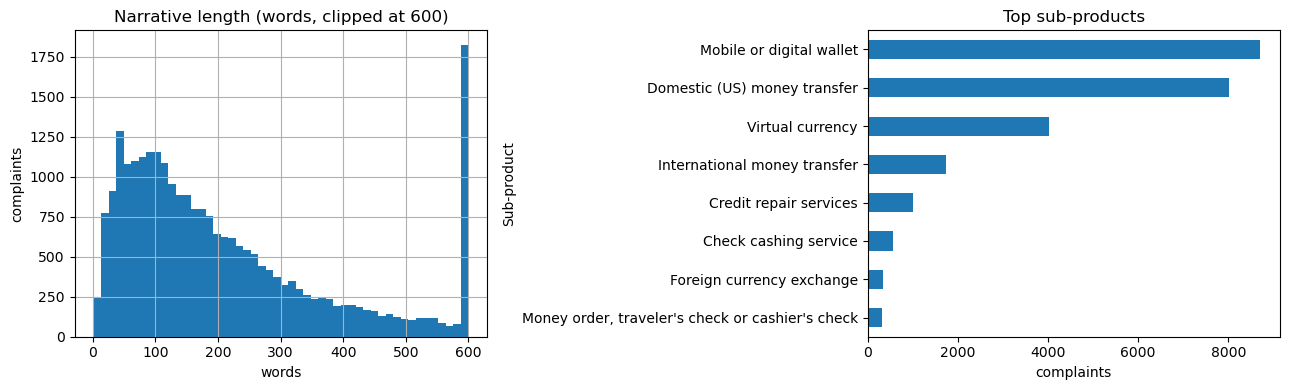

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

df["word_count"].clip(upper=600).hist(bins=50, ax=axes[0])
axes[0].set_title("Narrative length (words, clipped at 600)")
axes[0].set_xlabel("words"); axes[0].set_ylabel("complaints")

df[COL_SUB].value_counts().head(8).sort_values().plot.barh(ax=axes[1])
axes[1].set_title("Top sub-products")
axes[1].set_xlabel("complaints")

plt.tight_layout()
plt.savefig("exploration.png", dpi=120)
plt.show()


## 5. Preprocess and clean

Real complaint text is messy, so we clean it before modeling. Each step below
exists for a specific reason:

**Lowercasing** normalizes the text so the same word is not treated as two
different tokens based on capitalization.

**Removing CFPB redaction tokens.** The CFPB replaces names, account numbers,
dates, and dollar amounts with runs of X characters (XXXX) before publishing.
These carry no meaning and would add noise, so we strip them.

**Replacing currency markers.** Dollar amounts appear as {$1,234.00}. We swap
them for a neutral token so the model does not try to learn from specific dollar
figures.

**Stripping brand and platform names.** This is the most important step for our
project. Without it, the clustering groups complaints by which company was
mentioned, so all the PayPal complaints cluster together, all the Coinbase
complaints cluster together, and so on. We want clusters based on scam behavior,
not on company names, so we replace known brands with a neutral placeholder. This
forces the clustering to key on what actually happened, such as impersonation or
an urgent transfer request.

**Length filtering.** A one-word narrative cannot be clustered meaningfully, so
we drop narratives shorter than 10 words. We also truncate very long narratives
so they fit the model input limits.


In [6]:
# Brand and platform names that show up often in the money-transfer complaints
BRANDS = ["square","cash app","cashapp","venmo","paypal","zelle","stripe",
 "coinbase","binance","kraken","gemini","crypto.com","blockchain","bitcoin",
 "ethereum","western union","moneygram","remitly","wise","transferwise","xoom",
 "payoneer","skrill","revolut","chime","wells fargo","bank of america","chase",
 "citibank","citi","capital one","us bank","usaa","pnc","td bank","truist",
 "american express","amex","discover","visa","mastercard","apple pay",
 "google pay","samsung pay","robinhood","sofi","metabank","greendot",
 "green dot","netspend","walmart","money network","varo","current","dave",
 "affirm","klarna"]

# Compile the cleaning patterns once
_brand_pat = re.compile(
    r"\b(" + "|".join(re.escape(b) for b in sorted(BRANDS, key=len, reverse=True)) + r")\b",
    re.IGNORECASE)
_redact_pat = re.compile(r"\bX{2,}\b", re.IGNORECASE)     # XXXX redactions
_money_pat = re.compile(r"\{\$[\d,\.]+\}")             # {$1,234.00}
_space_pat = re.compile(r"\s+")

def clean_text(text):
    text = text.lower()
    text = _redact_pat.sub(" ", text)
    text = _money_pat.sub(" amount ", text)
    text = _brand_pat.sub(" company ", text)
    return _space_pat.sub(" ", text).strip()

# Show one example before and after so we can see the cleaning working
example = df[COL_NARR].iloc[0]
print("BEFORE:\n", example[:300], "\n")
print("AFTER:\n", clean_text(example)[:300])


BEFORE:
 According to Federal Law, XXXX is legal. I opened an online business. I used Square as my vehicle of payment. After 2 sales totaling {$950.00}, they deactivated my account saying it was a high risk business. I understand, XXXX is still misunderstood, but it helps millions of people deal with pain &  

AFTER:
 according to federal law, is legal. i opened an online business. i used company as my vehicle of payment. after 2 sales totaling amount , they deactivated my account saying it was a high risk business. i understand, is still misunderstood, but it helps millions of people deal with pain & anxiety. so


In [7]:
# Apply cleaning to the whole dataset
df["clean_text"] = df[COL_NARR].map(clean_text)

# Recompute word count on the cleaned text and length-filter
df["word_count"] = df["clean_text"].str.split().str.len()
before = len(df)
df = df[df["word_count"] >= MIN_WORDS].copy()
print(f"Dropped {before - len(df):,} narratives under {MIN_WORDS} words. "
      f"Remaining: {len(df):,}")

# Truncate long narratives
df["clean_text"] = df["clean_text"].map(lambda t: " ".join(t.split()[:MAX_WORDS]))

# Flag older-consumer complaints for the demographic research question
df["is_older"] = df[COL_TAGS].astype(str).str.contains(OLDER_TAG, na=False)

# Save the cleaned data
keep = [COL_ID, COL_PROD, COL_SUB, COL_TAGS, COL_NARR, "clean_text",
        "word_count", "is_older"]
df[keep].to_csv(CLEAN, index=False, compression="gzip")
print(f"Saved cleaned data to {CLEAN}")


Dropped 126 narratives under 10 words. Remaining: 25,651
Saved cleaned data to complaints_clean.csv.gz


## 6. A note on data augmentation

The rubric asks about data augmentation if applicable. For this project it is not
applicable at the discovery stage, and using it would work against our goal. Our
first phase is unsupervised discovery of real scam patterns, so injecting
synthetic or paraphrased complaints would distort the natural distribution of the
data and could create archetypes that do not actually exist in the real
complaints. We rely on the roughly 25,000 real narratives instead. If the
classifier later struggles on a rare archetype, class weighting during training
is a cleaner fix than augmentation, and that is what we use in Notebook 2.


## 7. Discover scam archetypes (Phase 1)

Now we find the scam archetypes. This is unsupervised, meaning we have no labels
telling us what kind of scam each complaint describes. We let the structure of the
data reveal the groupings.

**Why this pipeline.** We embed each narrative with a Sentence Transformer, reduce
the dimensions with UMAP, then cluster with HDBSCAN, tied together by BERTopic.

We chose this over older methods like LDA topic modeling because LDA treats text
as a bag of words and ignores sentence meaning, which produces incoherent topics
on short complaint text. Sentence Transformer embeddings capture meaning, so two
complaints that describe the same scam in different words still land near each
other.

We chose HDBSCAN over KMeans because KMeans forces every complaint into a cluster
and needs the number of clusters set in advance. HDBSCAN finds clusters of varying
density on its own and labels ambiguous complaints as noise, which is what we want
when we do not know how many scam types exist.


In [8]:
from sentence_transformers import SentenceTransformer
from umap import UMAP
from hdbscan import HDBSCAN
from bertopic import BERTopic

docs = df["clean_text"].tolist()

embedder = SentenceTransformer(EMBED_MODEL)
umap_model = UMAP(n_components=UMAP_N_COMPONENTS, n_neighbors=UMAP_N_NEIGHBORS,
                  min_dist=UMAP_MIN_DIST, random_state=SEED)
hdbscan_model = HDBSCAN(min_cluster_size=HDBSCAN_MIN_CLUSTER_SIZE,
                        metric="euclidean", cluster_selection_method="eom",
                        prediction_data=True, gen_min_span_tree=True)

topic_model = BERTopic(embedding_model=embedder, umap_model=umap_model,
                       hdbscan_model=hdbscan_model,
                       calculate_probabilities=False, verbose=True)

topics, _ = topic_model.fit_transform(docs)
df["archetype"] = topics

n_arch = len(set(topics)) - (1 if -1 in topics else 0)
print(f"Discovered {n_arch} archetypes.")
print(f"Noise complaints (unassigned): {(df['archetype'] == -1).sum():,}")


/home/tong.sam/.local/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2026-07-18 12:18:13.371044: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
Loading weights: 100%|██████████| 103/103 [00:00<00:00, 8363.60it/s]
2026-07-18 12:18:18,733 - BERTopic - Embedding - Transforming documents to embeddings.
Batches: 100%|██████████| 802/802 [03:01<00:00,  4.42it/s]
2026-07-18 12:21:20,379 - BERTopic - Embedding - Completed ✓
2026-07-18 12:21:20,380 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-07-18 12:22:10,468 - BERTopic - Dimensionality - C

Discovered 5 archetypes.
Noise complaints (unassigned): 2,922


In [9]:
# Look at the discovered topics and their keywords
topic_model.get_topic_info().head(15)


,Topic,Count,Name,Representation,Representative_Docs
0,-1,2922,-1_the_to_and_of,"[the, to, and, of, my, that, was, in, company,...",[i have used company for my hair cutting servi...
1,0,19812,0_the_to_and_my,"[the, to, and, my, company, was, that, of, the...","[on / /23, i received a text message from a pe..."
2,1,1459,1_the_check_to_and,"[the, check, to, and, was, that, my, me, of, on]",[i am resubmitting this issue due to the recen...
3,2,673,2_the_to_and_was,"[the, to, and, was, for, that, of, me, on, he]","[i went to see a home for rent at , , tx, , fr..."
4,3,417,3_layered_multi_deposits_fell,"[layered, multi, deposits, fell, involved, mak...","[commencing on or about / /year>, i fell victi..."
5,4,368,4_the_puppy_to_and,"[the, puppy, to, and, was, they, for, that, of...",[i was supposedly buying a puppy from a breede...


In [10]:
# Print the top keywords for each archetype so we can sanity-check them
for tid in sorted(set(topics)):
    if tid == -1:
        continue
    words = ", ".join(w for w, _ in topic_model.get_topic(tid)[:8])
    size = (df["archetype"] == tid).sum()
    older = df.loc[df["archetype"] == tid, "is_older"].mean() * 100
    print(f"Archetype {tid} (n={size:,}, older {older:.1f}%): {words}")


Archetype 0 (n=19,812, older 10.1%): the, to, and, my, company, was, that, of
Archetype 1 (n=1,459, older 6.1%): the, check, to, and, was, that, my, me
Archetype 2 (n=673, older 3.4%): the, to, and, was, for, that, of, me
Archetype 3 (n=417, older 12.9%): layered, multi, deposits, fell, involved, making, run, commencing
Archetype 4 (n=368, older 7.1%): the, puppy, to, and, was, they, for, that


## 8. Validate the archetypes

We check cluster quality two ways.

**DBCV (Density-Based Clustering Validation)** measures how well separated the
clusters are. We use this instead of the more common silhouette score because
silhouette assumes round, convex clusters, and text embedding clusters are not
shaped that way. DBCV is built for density-based clusters like the ones HDBSCAN
produces. Higher is better.

**C_v topic coherence** measures whether the keywords in each archetype actually
go together in a way that makes sense. Higher is better.


In [11]:
# DBCV from the fitted HDBSCAN model
try:
    dbcv = hdbscan_model.relative_validity_
    print(f"DBCV (relative validity): {dbcv:.3f}")
except Exception as e:
    print("DBCV not available:", e)

# C_v topic coherence
from gensim.corpora import Dictionary
from gensim.models.coherencemodel import CoherenceModel

topic_words = []
for tid in sorted(set(topics)):
    if tid == -1:
        continue
    words = [w for w, _ in topic_model.get_topic(tid)][:10]
    if words:
        topic_words.append(words)

tokenized = [d.split() for d in docs]
dictionary = Dictionary(tokenized)
cm = CoherenceModel(topics=topic_words, texts=tokenized,
                    dictionary=dictionary, coherence="c_v")
print(f"Mean C_v coherence: {cm.get_coherence():.3f}")


DBCV (relative validity): 0.040
Mean C_v coherence: 0.447


## 9. Build train, validation, and test splits

We split the labeled complaints 80/10/10 into training, validation, and test sets.
The split is stratified by archetype, which means each split keeps the same
proportion of each scam type. This matters because our archetypes are imbalanced,
and without stratification a rare archetype could end up almost entirely in one
split. We drop the noise complaints since they have no archetype label.


In [12]:
from sklearn.model_selection import train_test_split

labeled = df[df["archetype"] != -1].copy()

train_val, test = train_test_split(
    labeled, test_size=0.10, stratify=labeled["archetype"], random_state=SEED)
train, val = train_test_split(
    train_val, test_size=0.10/0.90, stratify=train_val["archetype"],
    random_state=SEED)

print(f"train: {len(train):,}")
print(f"val:   {len(val):,}")
print(f"test:  {len(test):,}")
print(f"archetypes: {labeled['archetype'].nunique()}")

# Save the labeled dataset for Notebook 2
labeled.to_csv(LABELED, index=False, compression="gzip")
train.to_csv("split_train.csv.gz", index=False, compression="gzip")
val.to_csv("split_val.csv.gz", index=False, compression="gzip")
test.to_csv("split_test.csv.gz", index=False, compression="gzip")
print(f"\nSaved labeled dataset and splits.")


train: 18,183
val:   2,273
test:  2,273
archetypes: 5

Saved labeled dataset and splits.


## Done

This notebook produced the cleaned, labeled dataset and the train, validation,
and test splits. Record the DBCV score, the C_v coherence, and the number of
archetypes for the documentation. Continue to Notebook 2 to develop and train the
classifier.
